In [1]:

import numpy as np 
import pandas as pd 


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub

/kaggle/input/datasets/larsen0966/student-performance-data-set/student-por.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/larsen0966/student-performance-data-set/student-por.csv')

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
print(df.columns.tolist()) 

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [5]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [6]:
# Create target variable
# G3 >= 10 → Pass (1)
# G3 < 10  → Fail (0)

df["result"] = (df["G3"] >= 10).astype(int)

print(df["result"].value_counts())

result
1    549
0    100
Name: count, dtype: int64


In [7]:
features = [
    "studytime",
    "failures",
    "absences",
    "Medu",
    "Fedu",
    "goout",
    "freetime",
    "health",
    "higher",
    "internet"
]

X = df[features].copy()
y = df["result"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   studytime  failures  absences  Medu  Fedu  goout  freetime  health higher  \
0          2         0         4     4     4      4         3       3    yes   
1          2         0         2     1     1      3         3       3    yes   
2          2         0         6     1     1      2         3       3    yes   
3          3         0         0     4     2      2         2       5    yes   
4          2         0         0     3     3      2         3       5    yes   

  internet  
0       no  
1      yes  
2      yes  
3      yes  
4       no  

Target:
0    1
1    1
2    1
3    1
4    1
Name: result, dtype: int64


In [8]:
print(X.dtypes)

studytime     int64
failures      int64
absences      int64
Medu          int64
Fedu          int64
goout         int64
freetime      int64
health        int64
higher       object
internet     object
dtype: object


In [9]:
X["higher"] = X["higher"].map({
    "yes": 1,
    "no": 0
})

X["internet"] = X["internet"].map({
    "yes": 1,
    "no": 0
})

print(X.dtypes)

studytime    int64
failures     int64
absences     int64
Medu         int64
Fedu         int64
goout        int64
freetime     int64
health       int64
higher       int64
internet     int64
dtype: object


In [10]:
print("Missing values in X:", X.isnull().sum().sum())

Missing values in X: 0


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 519
Testing samples: 130


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (519, 10)
X_test shape: (130, 10)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(10,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8627 - loss: 0.3324 - val_accuracy: 0.8654 - val_loss: 0.3211
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8506 - loss: 0.3317 - val_accuracy: 0.8654 - val_loss: 0.3227
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8602 - loss: 0.3300 - val_accuracy: 0.8654 - val_loss: 0.3213
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8602 - loss: 0.3282 - val_accuracy: 0.8654 - val_loss: 0.3225
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8554 - loss: 0.3279 - val_accuracy: 0.8654 - val_loss: 0.3222
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8578 - loss: 0.3267 - val_accuracy: 0.8654 - val_loss: 0.3221
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8578 - loss: 0.3251 - val_accuracy: 0.8654 - val_loss: 0.3227
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8627 - loss: 0.3249 - val_accuracy: 0.8654 - val_loss:

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Get predicted probabilities
y_probability = model.predict(X_test)

# Convert probabilities to 0 or 1
y_prediction = (y_probability >= 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_test, y_prediction)
precision = precision_score(y_test, y_prediction)
recall = recall_score(y_test, y_prediction)
f1 = f1_score(y_test, y_prediction)

print("Test Accuracy :", accuracy)
print("Precision     :", precision)
print("Recall        :", recall)
print("F1 Score      :", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_prediction,
    target_names=["Fail", "Pass"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_prediction))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Test Accuracy : 0.8846153846153846
Precision     : 0.9098360655737705
Recall        : 0.9652173913043478
F1 Score      : 0.9367088607594937

Classification Report:
              precision    recall  f1-score   support

        Fail       0.50      0.27      0.35        15
        Pass       0.91      0.97      0.94       115

    accuracy                           0.88       130
   macro avg       0.70      0.62      0.64       130
weighted avg       0.86      0.88      0.87       130


Confusion Matrix:
[[  4  11]
 [  4 111]]


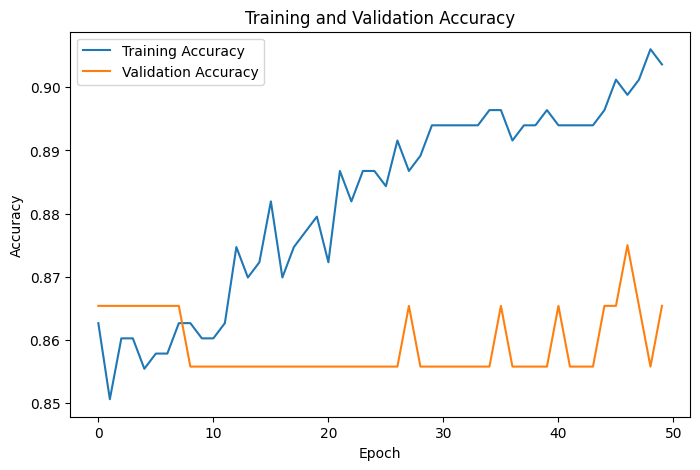

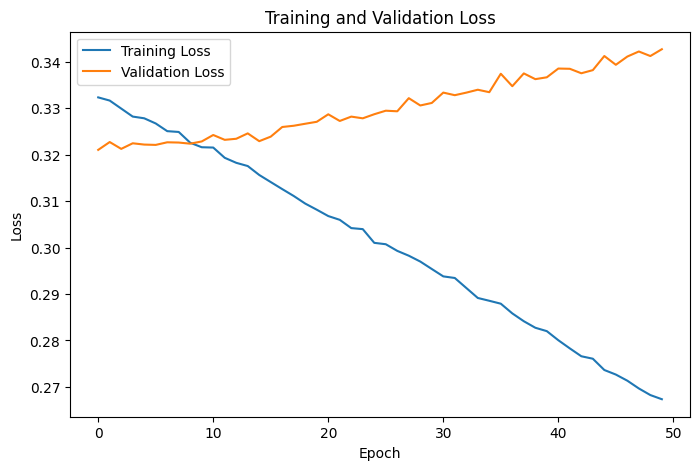

In [23]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


# Loss graph
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

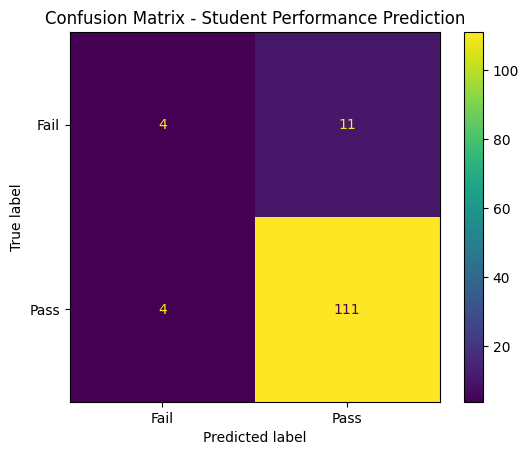

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()
plt.title("Confusion Matrix - Student Performance Prediction")
plt.show()

In [26]:
import pandas as pd

new_student = pd.DataFrame([{
    "studytime": 3,
    "failures": 0,
    "absences": 4,
    "Medu": 3,
    "Fedu": 3,
    "goout": 2,
    "freetime": 3,
    "health": 4,
    "higher": 1,
    "internet": 1
}])

# Scale using the same scaler
new_student_scaled = scaler.transform(new_student)

# Predict probability
probability = model.predict(new_student_scaled)[0][0]

# Convert probability to Pass/Fail
prediction = "PASS" if probability >= 0.5 else "FAIL"

print("Probability of Passing:", round(float(probability) * 100, 2), "%")
print("Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Probability of Passing: 98.41 %
Prediction: PASS
